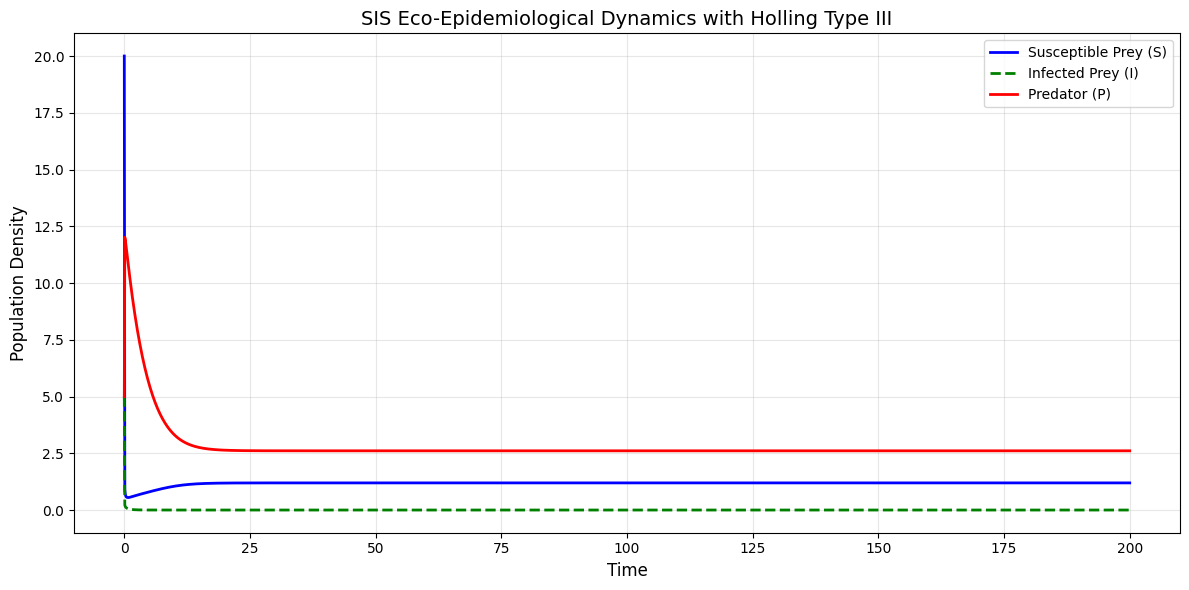

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

def sis_type3_model(y, t, r, K, beta, delta, mu, alpha, a, e, gamma):
    S, I, P = y
    N = S + I
    phi_N = (alpha * N**2) / (1 + a * N) if N > 0 else 0
    dSdt = r * N * (1 - N / K) - beta * S * I + delta * I - phi_N * S * P
    dIdt = beta * S * I - (delta + mu) * I - phi_N * I * P
    dPdt = e * phi_N * N * P - gamma * P
    return [dSdt, dIdt, dPdt]

params = {
    'r': 1.5,# Prey growth rate
    'K': 40.0,# Carrying capacity
    'beta': 0.8,# Infection rate
    'delta': 0.05,# Recovery rate
    'mu': 0.1,# Disease-induced mortality
    'alpha': 0.4,# Predator search efficiency
    'a': 0.02,# Saturation constant
    'e': 0.3,# Conversion efficiency
    'gamma': 0.2# Predator death rate
}
    
y0 = [20.0, 5.0, 5.0]  # [S, I, P]
t = np.linspace(0, 200, 2000)

sol = odeint(sis_type3_model, y0, t, args=(
    params['r'], params['K'], params['beta'], params['delta'], 
    params['mu'], params['alpha'], params['a'], params['e'], params['gamma']))

plt.figure(figsize=(12, 6))
plt.plot(t, sol[:, 0], label='Susceptible Prey (S)', color='blue', linewidth=2)
plt.plot(t, sol[:, 1], label='Infected Prey (I)', color='green', linewidth=2, linestyle='--')
plt.plot(t, sol[:, 2], label='Predator (P)', color='red', linewidth=2)
plt.title('SIS Eco-Epidemiological Dynamics with Holling Type III', fontsize=14)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Population Density', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()